In [1]:
import glob
import yaml
import pandas as pd

# Stats

In [2]:
config = yaml.safe_load(open("config.yaml"))
data_path = config["data_path"]
image_paths = sorted(
            glob.glob(data_path + f"/{config['images_folder']}/*.jpg")
        )

labelsA = pd.read_csv(data_path + f"/{config['lesion_file']}")
labelsB = pd.read_csv(data_path + f"/{config['shortcut_file']}")[["image", "ruler"]]


In [3]:
df = labelsB.merge(labelsA, on='image')[['image','ruler','MEL']]
df

,image,ruler,MEL
0,ISIC_0024306,0.0,0.0
1,ISIC_0024307,0.0,0.0
2,ISIC_0024308,0.0,0.0
3,ISIC_0024309,0.0,0.0
4,ISIC_0024310,1.0,1.0
...,...,...,...
10010,ISIC_0034316,0.0,1.0
10011,ISIC_0034317,0.0,1.0
10012,ISIC_0034318,0.0,0.0
10013,ISIC_0034319,0.0,0.0


In [4]:
ruler_mask = df['ruler'] == 1
MEL_mask   = df['MEL'] == 1

print("#Rulers" , df[ruler_mask].shape[0])
print("#MEL"    , df[MEL_mask].shape[0])
print()
print("#Rulers no MEL" , df[(ruler_mask & ~MEL_mask)].shape[0])
print("#MEL no ruler"  , df[(MEL_mask & ~ruler_mask)].shape[0])
print()
print("#both"   , df[MEL_mask & ruler_mask].shape[0])
print("#neither", df[~(MEL_mask | ruler_mask)].shape[0] )

#Rulers 1721
#MEL 1113

#Rulers no MEL 1427
#MEL no ruler 819

#both 294
#neither 7475


# Confusion Matrix

In [5]:
df = pd.read_csv('results_lists.csv').astype(int)
df

,prediction,true_label,shortcut_flag
0,0,0,0
1,1,1,1
2,1,1,1
3,0,0,0
4,0,0,0
...,...,...,...
1747,1,1,0
1748,1,1,0
1749,1,1,1
1750,1,1,0


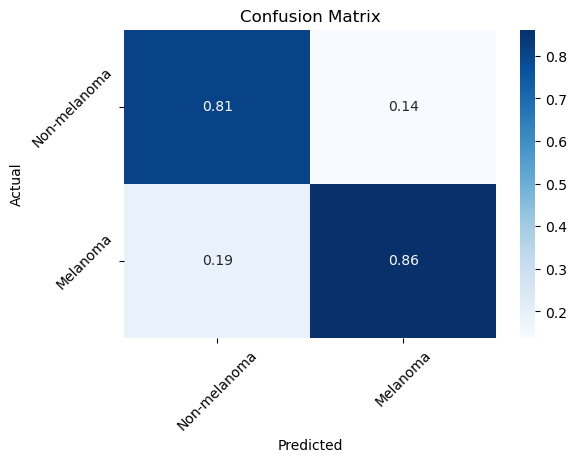

In [7]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

cm = confusion_matrix(df['true_label'], df['prediction'])
labels = ["Non-melanoma", "Melanoma"]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Plot with seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df / cm_df.sum(axis=0), annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title('Confusion Matrix')
plt.show()